<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Prueba_de_frecuencias_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prueba de frecuencias**

La **prueba de las frecuencias** es un maétodo utilizado para determinar si un conjunto de datos observados se ajusta a la distribución esperada, *comparamos si las frecuencias observadas difiieren de las frecuencias que se esperaban*

In [56]:
#Importamos las bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import pandas as pd

Ocupando estos datos:


In [57]:
df=pd.read_excel("datos_prueba_promedios.xlsx") #Aquí cargamos el archivo de excel con los datos
datos=df['Datos'].dropna().values   #Lo pasamos a un arreglo, la columna con el nombre 'Datos' es donde estan todos los números

Queremos imprimir estos datos en la tabla:
$$F_0 \quad | \quad F_e \quad | \quad (F_0-F_e) \quad | \quad (F_0-F_e)^2 \quad | \quad \frac{(F_0-F_e)^2}{F_e}$$

In [58]:
n=len(datos) #Tamaño de la muestra
k=5 #No. de intervalos

intervalos=np.linspace(0, 1, k+1) #Creamos los intervalos

Fo, _ =np.histogram(datos, bins=intervalos) #Contamos cuántos datos caen en cada intervalo (frecuencia observada)
Fe = np.ones(k)*n/k #Si la distribución es uniforme entonces Fe=n/k

#Cálculos que ocupamos para formar la tabla
diferencia=Fo-Fe
diferencia2=diferencia**2
chi_individual=diferencia2/Fe
chi_total=np.sum(chi_individual)

In [59]:
#Imprimimos la tabla
print(" Intervalo     Fo    Fe    Fo-Fe      (Fo-Fe)^2    (Fo-Fe)^2/Fe")
print("---------------------------------------------------------------")

for i in range(k):
    print(f"[{intervalos[i]:.1f}-{intervalos[i+1]:.1f}]"
          f"    {Fo[i]:3d}  {Fe[i]:6.2f}  {diferencia[i]:7.2f}"
          f"   {diferencia2[i]:10.2f}   {chi_individual[i]:10.4f}")

print("\nEstadístico χ² calculado =", round(chi_total,6)) #Imprimimos el chi calculado



 Intervalo     Fo    Fe    Fo-Fe      (Fo-Fe)^2    (Fo-Fe)^2/Fe
---------------------------------------------------------------
[0.0-0.2]     21   20.00     1.00         1.00       0.0500
[0.2-0.4]     22   20.00     2.00         4.00       0.2000
[0.4-0.6]     19   20.00    -1.00         1.00       0.0500
[0.6-0.8]     23   20.00     3.00         9.00       0.4500
[0.8-1.0]     15   20.00    -5.00        25.00       1.2500

Estadístico χ² calculado = 2.0


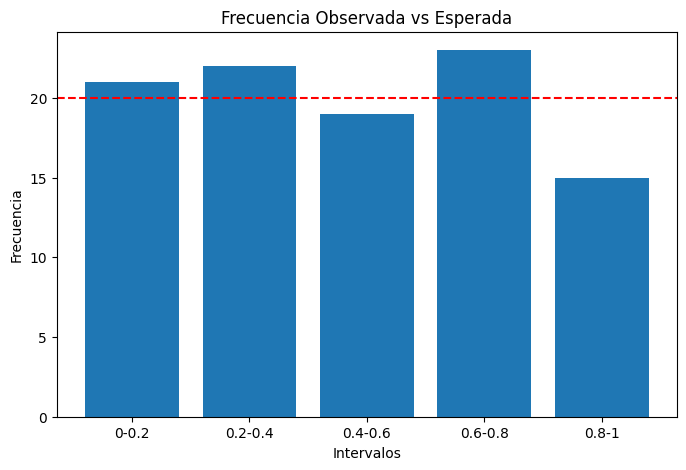

In [60]:
#Gráfica de las frecuencias
plt.figure(figsize=(8,5))
plt.bar(range(k), Fo) #Barras de la frecuencia observada
plt.axhline(y=Fe[0],linestyle='--', color='red') #Línea horizontal de la frecuencia esperada solo ocupoamos un elemento del arreglo

plt.xticks(range(k), ['0-0.2','0.2-0.4','0.4-0.6','0.6-0.8','0.8-1'])
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")
plt.title("Frecuencia Observada vs Esperada")

plt.show()